In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
from skopt import gp_minimize
from skopt.space import Real, Integer
from skopt.utils import use_named_args
import skopt.plots as skplt
import matplotlib.pyplot as plt
from pathlib import Path

# Import your existing pipeline functions
from RaTag.io.bootstrap import bootstrap_from_config
from RaTag.io.file_ops import iter_waveforms
from RaTag.el_tpc.drift_workflow import map_drift_physics
from RaTag.el_tpc.waveform_features import find_s1, find_s2, compute_timing_statistics


In [45]:
selected_sets[0].source_dir.name

'FieldScan_Gate0050_Anode1950'

In [17]:
# 1. Define representative dataset
# load list of all SetPmt objects

ROOT_DIR = "/Users/pabloherrero/sabat/RaTagging/configs/recoils/"
run_subdirs = ["run8", "run26", "run29", 
               "run10", "run24", "run30"]
             
MAX_FILES = 10 # Strict limit

full_run_configs = [ROOT_DIR/ Path(sb+'_analysis.yaml') for sb in run_subdirs]
runs_init = [bootstrap_from_config(cfg) for cfg in full_run_configs]
runs_drift = [map_drift_physics(run) for run in runs_init]

Found 9 set directories in RUN8_EL2350Vcm_5GSsec: ['FieldScan_Gate0050_Anode1950', 'FieldScan_Gate0100_Anode2000', 'FieldScan_Gate0200_Anode2100', 'FieldScan_Gate0300_Anode2200', 'FieldScan_Gate0400_Anode2300', 'FieldScan_Gate0500_Anode2400', 'FieldScan_Gate0600_Anode2500', 'FieldScan_Gate0800_Anode2700', 'FieldScan_Gate1100_Anode3000']
  Found 2037 .wfm files in FieldScan_Gate0050_Anode1950
  Found 2008 .wfm files in FieldScan_Gate0100_Anode2000
  Found 2000 .wfm files in FieldScan_Gate0200_Anode2100
  Found 2000 .wfm files in FieldScan_Gate0300_Anode2200
  Found 2000 .wfm files in FieldScan_Gate0400_Anode2300
  Found 2000 .wfm files in FieldScan_Gate0500_Anode2400
  Found 2000 .wfm files in FieldScan_Gate0600_Anode2500
  Found 2000 .wfm files in FieldScan_Gate0800_Anode2700
  Found 2000 .wfm files in FieldScan_Gate1100_Anode3000
Found 8 set directories in RUN26_Th228_EL2700: ['FieldScan_Gate0050_Anode2750', 'FieldScan_Gate0100_Anode2800', 'FieldScan_Gate0200_Anode2900', 'FieldScan_Ga

In [18]:
selected_sets = [r.sets for r in runs_drift]  # This will be a list of lists (one per run)
selected_sets = [s for sublist in selected_sets for s in sublist]  #
selected_sets = selected_sets[:4]  

In [19]:

# 2. Define the Hyperparameter Search Space
# We are optimizing 'N' (sigma multiplier) rather than raw voltage.
space = [
    Real(2.0, 10.0, name='N_s1'),          # S1 Threshold multiplier
    Real(1.5, 8.0, name='N_s2'),           # S2 Threshold multiplier
    Integer(5, 50, name='window_size'),    # S2 Smoothing window
    Real(0.005, 0.05, name='threshold_bs'),# Baseline suppression
    Real(0.1, 0.7, name='t_drift_margin')  # Margin for t_min
]


In [ ]:
# 3. The Objective Function
@use_named_args(space)
def objective(N_s1, N_s2, window_size, threshold_bs, t_drift_margin):
    total_loss = 0.0
    valid_sets = 0
    
    for set_pmt in selected_sets:
        # Context extraction: get the noise floor for this specific set
        # Assuming set_pmt has an attribute for baseline noise sigma. 
        # If not, you'd calculate this from the first few waveforms.
        sample_wfs = list(iter_waveforms(set_pmt, max_files=2))
        if not sample_wfs:
            continue # Skip if set is empty
            
        # Extract the pre-trigger region (e.g., first 200 points as in find_s1)
        # We calculate the standard deviation across this region for our sample
        n_points = 200
        noise_samples = [np.std(wf.v[:, :n_points]) if wf.ff else np.std(wf.v[:n_points]) for wf in sample_wfs]
        
        # Use the median of these standard deviations to protect against 
        # a random early pre-trigger pulse skewing the noise estimate
        noise_sigma = np.median(noise_samples)
        
        # Now apply the BO multiplier (N) to the physical noise floor
        
        threshold_s1 = noise_sigma * N_s1
        threshold_s2 = noise_sigma * N_s2
        
        t_drift_margin_time = (set_pmt.time_drift or 0.0) * t_drift_margin
        
        # Buffers for this set
        out_s1, out_s2_start, out_s2_end = [], [], []
        s1_anchor = -5.0
        
        for wf in iter_waveforms(set_pmt, max_files=MAX_FILES):
            t_s1 = find_s1(wf, threshold=threshold_s1, t_max=-2.5)
            if not np.all(np.isnan(t_s1)):
                s1_anchor = np.nanmean(t_s1)
                
            t_s2_st, t_s2_end = find_s2(
                wf, 
                threshold_s2=threshold_s2, 
                t_min=s1_anchor + t_drift_margin_time, 
                window_size=int(window_size), 
                threshold_bs=threshold_bs
            )
            
            out_s1.append(t_s1)
            out_s2_start.append(t_s2_st)
            out_s2_end.append(t_s2_end)
            
        # Compute Stats
        s1_arr = np.concatenate(out_s1)
        s2_starts = np.concatenate(out_s2_start)
        s2_ends = np.concatenate(out_s2_end)
        
        valid_mask = ~np.isnan(s2_starts) & ~np.isnan(s2_ends)
        s2_widths = s2_ends[valid_mask] - s2_starts[valid_mask]
        
        # 4. Compute standard deviations
        std_s1 = compute_timing_statistics(s1_arr, name="t_s1").get("t_s1_std", 0.0)
        std_s2_start = compute_timing_statistics(s2_starts, name="t_s2_start").get("t_s2_start_std", 0.0)
        
        std_s2_width = compute_timing_statistics(s2_widths, name="s2_width").get("s2_width_std", 0.0)
        
        # 5. Adjusted Penalty Logic
        if std_s1 == 0.0 or std_s2_start == 0.0 or std_s2_width == 0.0:
            set_loss = 100.0  # High penalty for finding nothing
        else:
            # We add a physical constraint: 
            # If the median S2 width is suspiciously tiny (e.g., < 1.0 us), 
            # it means the BO set the threshold too high and chopped off the tail.
            # We penalize this to force it to capture the full pulse.
            median_width = np.median(s2_widths)
            width_penalty = 10.0 if median_width < 1.0 else 0.0 
            
            # The new loss function
            set_loss = std_s1 + std_s2_start + std_s2_width + width_penalty
            valid_sets += 1

        total_loss += set_loss
        
    # Return average loss across all physical contexts
    return total_loss / len(selected_sets)

In [31]:
# 4. Run the Gaussian Process Optimization
res_gp = gp_minimize(
    objective, 
    space, 
    n_calls=40,       # Total number of iterations
    n_random_starts=10, # Initial random exploration before GP takes over
    random_state=42,
    verbose=True
)

print(f"Best score (Combined STD): {res_gp.fun:.4f}")
print(f"Optimal N_s1: {res_gp.x[0]:.2f}")
print(f"Optimal N_s2: {res_gp.x[1]:.2f}")
print(f"Optimal N_s2_end: {res_gp.x[2]:.2f}")
print(f"Optimal window_size: {res_gp.x[3]}")
print(f"Optimal threshold_bs: {res_gp.x[4]:.4f}")
print(f"Optimal t_drift_margin: {res_gp.x[5]:.4f}")

Iteration No: 1 started. Evaluating function at random point.
Iteration No: 1 ended. Evaluation done at random point.
Time taken: 19.1887
Function value obtained: 7.4962
Current minimum: 7.4962
Iteration No: 2 started. Evaluating function at random point.
Iteration No: 2 ended. Evaluation done at random point.
Time taken: 8.4094
Function value obtained: 7.3665
Current minimum: 7.3665
Iteration No: 3 started. Evaluating function at random point.
Iteration No: 3 ended. Evaluation done at random point.
Time taken: 9.2062
Function value obtained: 6.5355
Current minimum: 6.5355
Iteration No: 4 started. Evaluating function at random point.
Iteration No: 4 ended. Evaluation done at random point.
Time taken: 4.0744
Function value obtained: 7.3315
Current minimum: 6.5355
Iteration No: 5 started. Evaluating function at random point.
Iteration No: 5 ended. Evaluation done at random point.
Time taken: 7.6522
Function value obtained: 8.3137
Current minimum: 6.5355
Iteration No: 6 started. Evaluatin

In [39]:
res_gp.x[2:]
print("Optimal window_size:", res_gp.x[2])
print("Optimal threshold_bs:", res_gp.x[3])
print("Optimal t_drift_margin:", res_gp.x[4])

Optimal window_size: 35
Optimal threshold_bs: 0.04362049285311318
Optimal t_drift_margin: 0.6869278983426127


# Validation

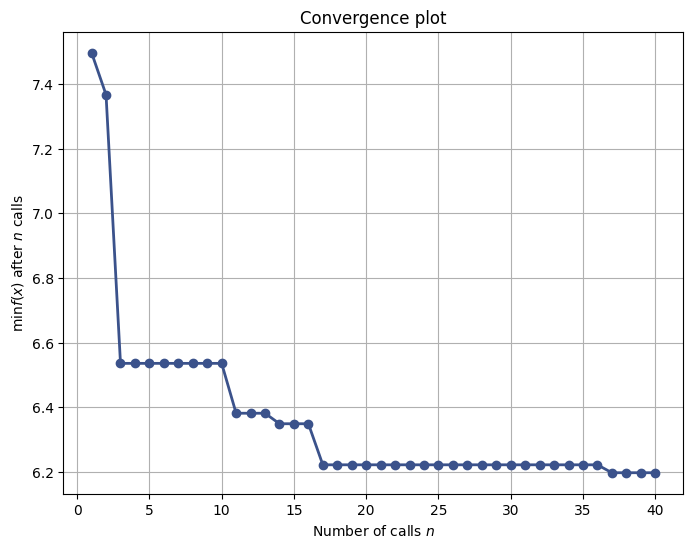

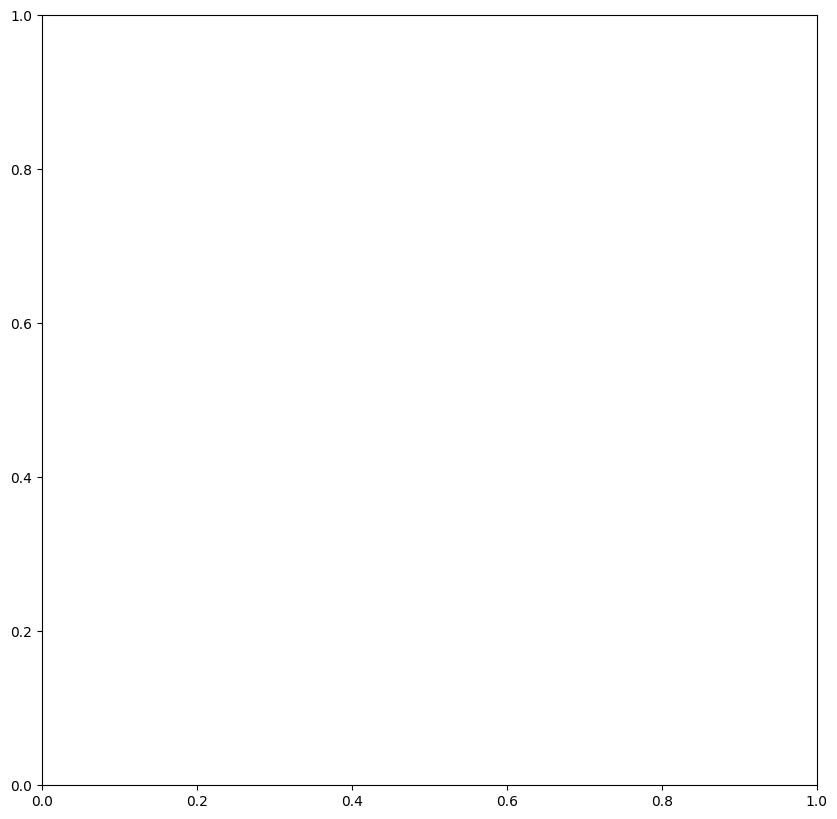

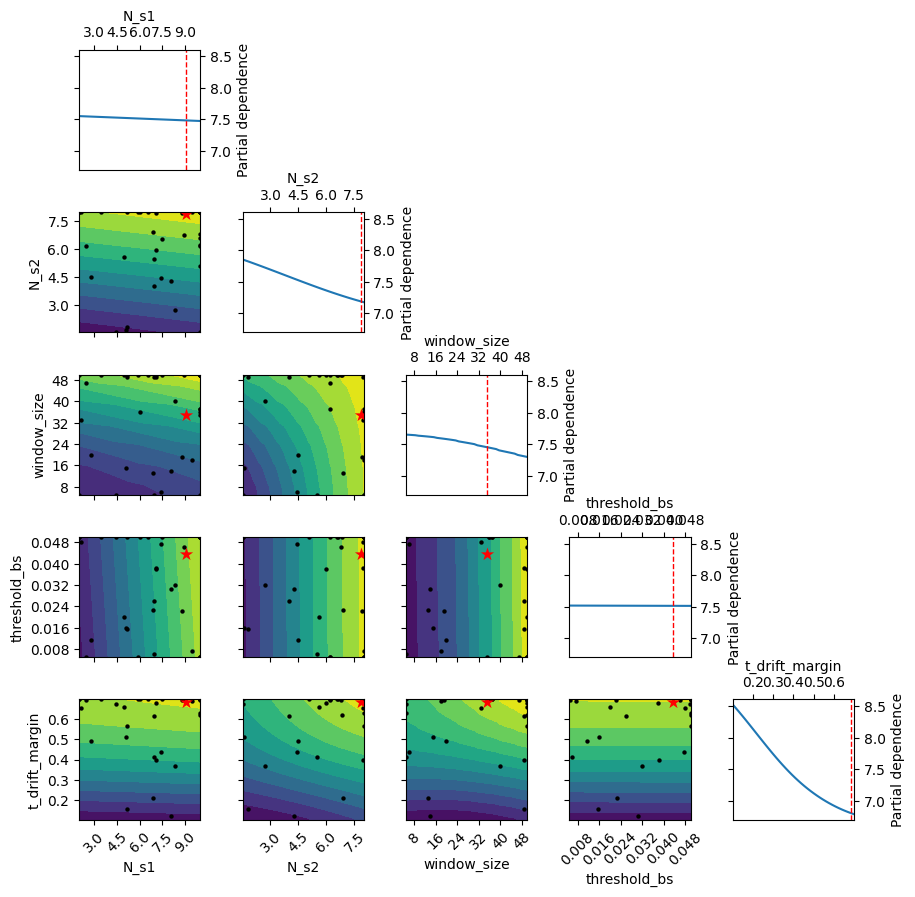

In [33]:
import skopt.plots as skplt
import matplotlib.pyplot as plt

# 1. Check Convergence: Did the score actually go down and plateau?
fig, ax = plt.subplots(figsize=(8, 6))
skplt.plot_convergence(res_gp, ax=ax)

# 2. Check Parameter Importance: Did all parameters matter?
# This shows the landscape of your objective function.
fig, ax = plt.subplots(figsize=(10, 10))
skplt.plot_objective(res_gp)
plt.show()

In [35]:
res_gp.x

[9.05710702173485,
 7.882348088043752,
 np.int64(35),
 0.04362049285311318,
 0.6869278983426127]

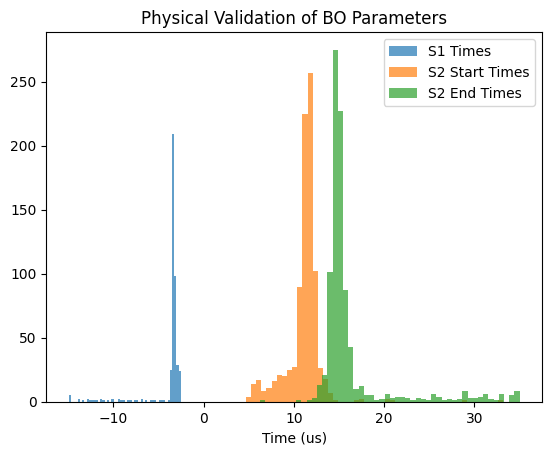

In [42]:
# Create a test payload using your best parameters
set_pmt = selected_sets[2] # Pick one run
noise_sigma = np.median([np.std(wf.v[:, :200]) if wf.ff else np.std(wf.v[:200]) 
                         for wf in iter_waveforms(set_pmt, max_files=50)])

# Apply the parameters
t_drift_time = (set_pmt.time_drift or 0.0) * res_gp.x[4]  # t_drift_margin
out_s1, out_s2_start, out_s2_end = [], [], []

for wf in iter_waveforms(set_pmt, max_files=20):
    t_s1 = find_s1(wf, threshold=noise_sigma * res_gp.x[0], t_max=-2.5)
    s1_anchor = np.nanmean(t_s1) if not np.all(np.isnan(t_s1)) else -5.0
    
    t_s2_st, t_s2_end = find_s2(wf, threshold_s2=noise_sigma * res_gp.x[1], 
                         t_min=s1_anchor + t_drift_time, 
                         window_size=res_gp.x[2], threshold_bs=res_gp.x[3])
    
    out_s1.append(t_s1)
    out_s2_start.append(t_s2_st)
    out_s2_end.append(t_s2_end)

# Plot the physics!
s1_times = np.concatenate(out_s1)
s2_times = np.concatenate(out_s2_start)
s2_end_times = np.concatenate(out_s2_end)

plt.hist(s1_times[~np.isnan(s1_times)], bins=50, alpha=0.7, label='S1 Times')
plt.hist(s2_times[~np.isnan(s2_times)], bins=50, alpha=0.7, label='S2 Start Times')
plt.hist(s2_end_times[~np.isnan(s2_end_times)], bins=50, alpha=0.7, label='S2 End Times')
plt.legend()
plt.title("Physical Validation of BO Parameters")
plt.xlabel("Time (us)")
plt.show()